In [1]:
import numpy as np
import math 
import matplotlib.pyplot as plt
import csv
from csv import writer
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator

In [2]:
filename='lakeshore_log_2025-01-27T20-40-37'
filename1='temperature_log_2025-02-06T01-57-48'

In [3]:
# Lakeshore
data_temp_1 = np.loadtxt(filename+".txt", usecols=5, skiprows=4, dtype='float',delimiter=",") 
data_temp_2 = np.loadtxt(filename+".txt", usecols=7, skiprows=4, dtype='float',delimiter=",") 
data_date =  np.loadtxt(filename+".txt", usecols=0, skiprows=4, dtype='str') 
data_time1 =  np.loadtxt(filename+".txt", usecols=0, skiprows=4, dtype='str',delimiter=",") 
data_time=np.empty(len(data_time1),dtype='U10')
for i in range(len(data_time1)):
    data_time[i]=data_time1[i].split(' ')[1]

In [4]:
data_time_coarse=np.empty(len(data_time1),dtype='U10')

j=0
for i in range(len(data_time)):
    if i%4==0:
        data_time_coarse[j]=data_time[i]
        j+=1

data_time_coarse = np.array([i for i in data_time_coarse if i])

data_temp1_coarse=np.zeros(len(data_time_coarse))
data_temp2_coarse=np.zeros(len(data_time_coarse))

j=0
for i in range(len(data_temp_1)):
    if i%4==0:
        data_temp1_coarse[j]=data_temp_1[i]
        data_temp2_coarse[j]=data_temp_2[i]
        j+=1

data_temp1_coarse = np.array([i for i in data_temp1_coarse if i])
data_temp2_coarse = np.array([i for i in data_temp2_coarse if i])

In [5]:
data_time_coarse

array(['18:21:02', '18:21:10', '18:21:18', ..., '02:10:14', '02:10:22',
       '02:10:30'], dtype='<U8')

In [6]:
# Cryo cooler
data_temp_cryo = np.loadtxt(filename1+".txt", usecols=1, skiprows=4, dtype='float',delimiter=",") 
data_timestamp_cryo = np.loadtxt(filename1+".txt", usecols=1, skiprows=4, dtype='str') 
data_date_cryo =  np.loadtxt(filename1+".txt", usecols=0, skiprows=4, dtype='str') 

time_stamps_cryo=np.empty(len(data_timestamp_cryo), dtype = 'S20')
for j in range(len(data_timestamp_cryo)):
    count=-1
    for i in data_timestamp_cryo[j]:
        count+=1
        if i==',':
            #print(count)
            time_stamps_cryo[j]=data_timestamp_cryo[j][:count]
        
#data_timestamp[0]

In [7]:
len(data_time)/4

3522.0

In [8]:
len(time_stamps_cryo)

5877

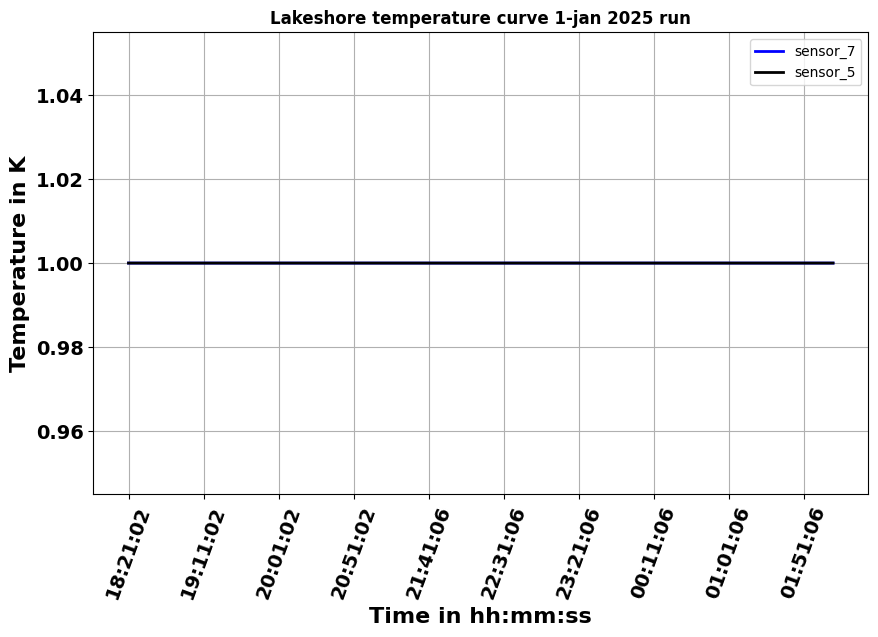

In [9]:
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(data_time,data_temp_1,'b-',linewidth=2,label='sensor_7')
plt.plot(data_time,data_temp_2,'k-',linewidth=2,label='sensor_5')
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
plt.title("Lakeshore temperature curve 1-jan 2025 run",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()

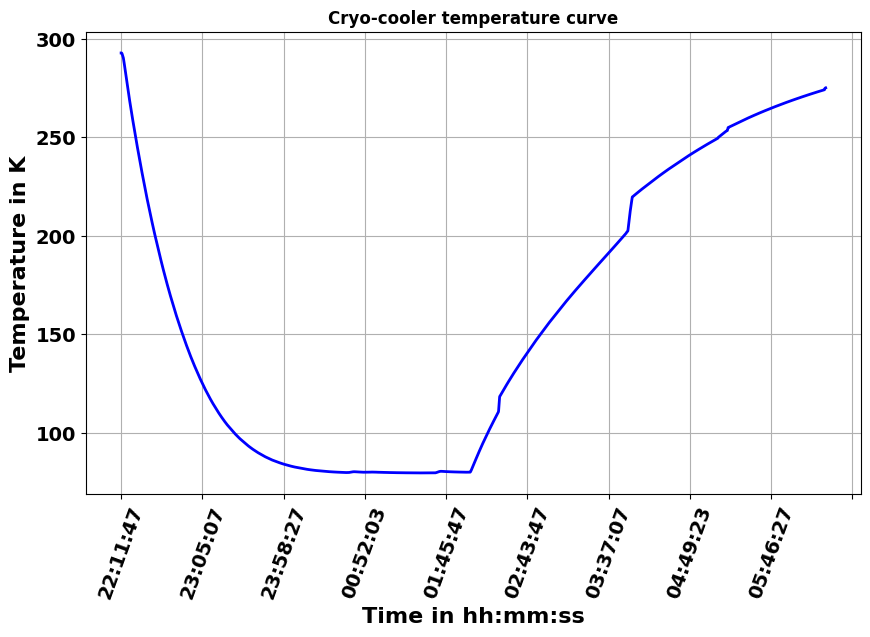

In [20]:
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(time_stamps_cryo,data_temp_cryo,'b-',linewidth=2)
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
plt.title("Cryo-cooler temperature curve",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.grid()
plt.show()

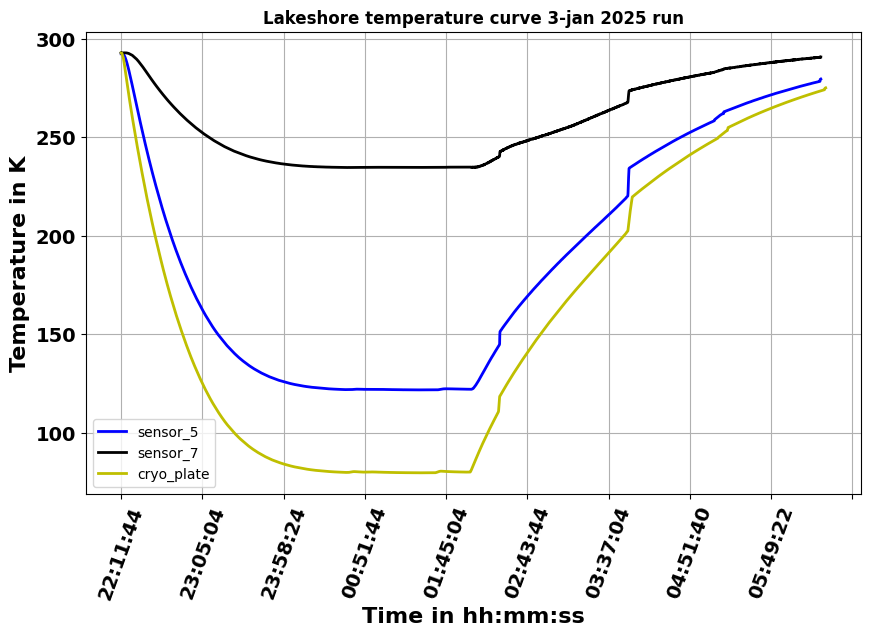

In [21]:
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(data_time_coarse,data_temp1_coarse,'b-',linewidth=2,label='sensor_5')
plt.plot(data_time_coarse,data_temp2_coarse,'k-',linewidth=2,label='sensor_7')
plt.plot(data_temp_cryo,'y-',linewidth=2,label='cryo_plate')
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
plt.title("Lakeshore temperature curve 3-jan 2025 run",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.grid()
plt.legend()
plt.show()